In [1]:
# Cell 1: Setup
import caspy
import numpy as np
import matplotlib.pyplot as plt

print(f"✓ CASPy version: {caspy.__version__}")

✓ CASPy version: 0.1.0


In [2]:
# Cell 2: Test all oscillators
sample_rate = 48000
duration = 0.1  # 100ms
num_samples = int(sample_rate * duration)

oscillators = {
    'Sine': caspy.Sine(),
    'Saw': caspy.Saw(),
    'Square': caspy.Square(),
    'Triangle': caspy.Triangle(),
}

for name, osc in oscillators.items():
    osc.set_frequency(440.0, sample_rate)
    samples = osc.render(num_samples)
    print(f"✓ {name:8s}: {len(samples)} samples, range [{min(samples):+.3f}, {max(samples):+.3f}]")


✓ Sine    : 4800 samples, range [-1.000, +1.000]
✓ Saw     : 4800 samples, range [-0.982, +0.982]
✓ Square  : 4800 samples, range [-1.000, +1.000]
✓ Triangle: 4800 samples, range [-1.022, +0.959]


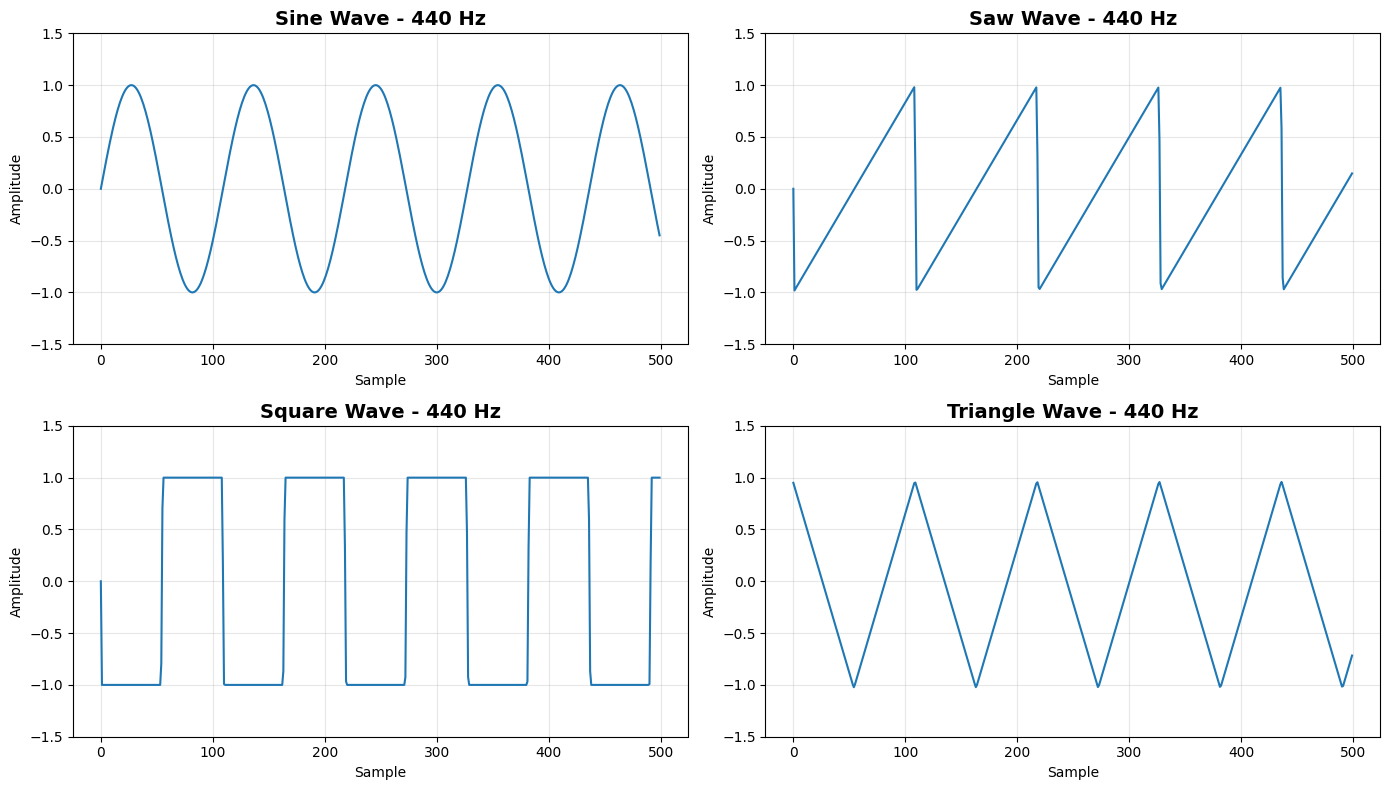

In [9]:
# Cell 3: Visualize waveforms
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (name, osc) in enumerate(oscillators.items()):
    osc.reset_phase()  # Start from same phase
    osc.set_frequency(440.0, sample_rate)
    samples = osc.render(500)  # Just show 500 samples
    
    axes[idx].plot(samples, linewidth=1.5)
    axes[idx].set_title(f"{name} Wave - 440 Hz", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Sample")
    axes[idx].set_ylabel("Amplitude")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

In [8]:
# Cell 4: Play audio (optional - requires sounddevice)
try:
    import sounddevice as sd
    volume = 0.1 # BE CAREFUL MAKING THIS LOUDER
    # Create a short beep
    osc = caspy.Saw()
    osc.set_frequency(220.0, sample_rate)
    beep = volume * osc.render(4 * sample_rate) 
    
    print("Playing 440 Hz saw wave...")
    sd.play(beep, sample_rate)

    sd.wait()
    print("Done!")
    
except ImportError:
    print("sounddevice not installed - skipping audio playback")
    print("Install with: uv pip install sounddevice")

Playing 440 Hz saw wave...
Done!
